# 🏠 House Price Prediction
**Internship Project — Week 1**  
**Dataset:** Housing Prices Dataset (Kaggle — yasserh)  
**Tools:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn

---

## Task 1 — Data Loading & Exploration

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.63k/4.63k [00:00<00:00, 3.20MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1


In [ ]:
# Load the dataset
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('Housing.csv')

# Display first 10 rows
print("📋 First 10 rows of the dataset:")
df.head(10)


Saving Housing.csv to Housing.csv
📋 First 10 rows of the dataset:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
# Shape of the dataset
print(f"📐 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n🎯 Target Column : price")
print(f"📦 Feature Columns: {[c for c in df.columns if c != 'price']}")


📐 Dataset Shape: 545 rows × 13 columns

🎯 Target Column : price
📦 Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [ ]:
# Check for missing values
print("🔍 Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\n📊 Data Types:")
print(df.dtypes)
print(df.columns)


🔍 Missing Values per Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values: 0

📊 Data Types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [ ]:
# Basic statistics
print("📈 Descriptive Statistics:")
df.describe()


📈 Descriptive Statistics:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Task 2 — Data Cleaning

In [ ]:
# Check and remove duplicates
print(f"🔁 Duplicate rows before cleaning: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"🔁 Duplicate rows after cleaning : {df.duplicated().sum()}")
print(f"\n✅ Dataset shape after cleaning: {df.shape}")


🔁 Duplicate rows before cleaning: 0
🔁 Duplicate rows after cleaning : 0

✅ Dataset shape after cleaning: (545, 13)


In [ ]:
# Handle missing values — none found, but showing the pattern
# For numerical columns: fill with median
# For categorical columns: fill with mode
# (No missing values in this dataset, but applying defensive code)
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("✅ Missing values handled.")
print(df.isnull().sum())


✅ Missing values handled.
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Categorical columns in your dataset
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

# Create encoder
le = LabelEncoder()

# Encode each column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Categorical columns encoded:")
print(df[categorical_cols].head())

✅ Categorical columns encoded:
   mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea  \
0         1          0         0                0                1         1   
1         1          0         0                0                1         0   
2         1          0         1                0                0         1   
3         1          0         1                0                1         1   
4         1          1         1                0                1         0   

   furnishingstatus  
0                 0  
1                 0  
2                 1  
3                 0  
4                 0  


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Categorical columns in your dataset
# The columns 'city', 'statezip', and 'country' do not exist in the current DataFrame.
# All existing categorical columns ('mainroad', 'guestroom', 'basement', 'hotwaterheating',
# 'airconditioning', 'prefarea', 'furnishingstatus') were already encoded in the previous cell.
categorical_cols = []

# Create encoder
le = LabelEncoder()

# Encode each column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Categorical columns encoded:")
# Only print if there are columns to display, otherwise indicate no new encodings.
if categorical_cols:
    print(df[categorical_cols].head())
else:
    print("No new categorical columns were encoded as 'city', 'statezip', and 'country' are not in the dataset.")

✅ Categorical columns encoded:
No new categorical columns were encoded as 'city', 'statezip', and 'country' are not in the dataset.


## Task 3 — Model Building & Evaluation

In [ ]:
# Split into features and target
X = df.drop('price', axis=1)
y = df['price']

# Train / Test split — 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Data split complete:")
print(f"   Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Test set     : {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)")
print(f"   Features     : {X_train.shape[1]}")


✅ Data split complete:
   Training set : 436 samples (80%)
   Test set     : 109 samples (20%)
   Features     : 12


In [ ]:
# ── Model 1: Linear Regression ──────────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("📐 Linear Regression Results:")
print(f"   MAE  (Mean Absolute Error)  : ₹{mae_lr:>12,.0f}")
print(f"   RMSE (Root Mean Sq. Error)  : ₹{rmse_lr:>12,.0f}")
print(f"   R²   (R-Squared Score)      :  {r2_lr:.4f}  ({r2_lr*100:.2f}% variance explained)")


📐 Linear Regression Results:
   MAE  (Mean Absolute Error)  : ₹     979,680
   RMSE (Root Mean Sq. Error)  : ₹   1,331,071
   R²   (R-Squared Score)      :  0.6495  (64.95% variance explained)


In [ ]:
# ── Model 2: Random Forest Regressor ────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("🌲 Random Forest Regressor Results:")
print(f"   MAE  (Mean Absolute Error)  : ₹{mae_rf:>12,.0f}")
print(f"   RMSE (Root Mean Sq. Error)  : ₹{rmse_rf:>12,.0f}")
print(f"   R²   (R-Squared Score)      :  {r2_rf:.4f}  ({r2_rf*100:.2f}% variance explained)")


🌲 Random Forest Regressor Results:
   MAE  (Mean Absolute Error)  : ₹   1,025,290
   RMSE (Root Mean Sq. Error)  : ₹   1,401,263
   R²   (R-Squared Score)      :  0.6115  (61.15% variance explained)


In [ ]:
# ── Model Comparison Table ───────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Metric': ['MAE (₹)', 'RMSE (₹)', 'R² Score'],
    'Linear Regression': [f'{mae_lr:,.0f}', f'{rmse_lr:,.0f}', f'{r2_lr:.4f}'],
    'Random Forest':     [f'{mae_rf:,.0f}', f'{rmse_rf:,.0f}', f'{r2_rf:.4f}']
})
print("📊 Model Comparison:")
print(comparison.to_string(index=False))

better = "Linear Regression" if r2_lr > r2_rf else "Random Forest"
print(f"\n🏆 Better Model (by R²): {better}")


📊 Model Comparison:
  Metric Linear Regression Random Forest
 MAE (₹)           979,680     1,025,290
RMSE (₹)         1,331,071     1,401,263
R² Score            0.6495        0.6115

🏆 Better Model (by R²): Linear Regression


## Task 4 — Visualizations

### Chart 1 — Distribution of House Prices

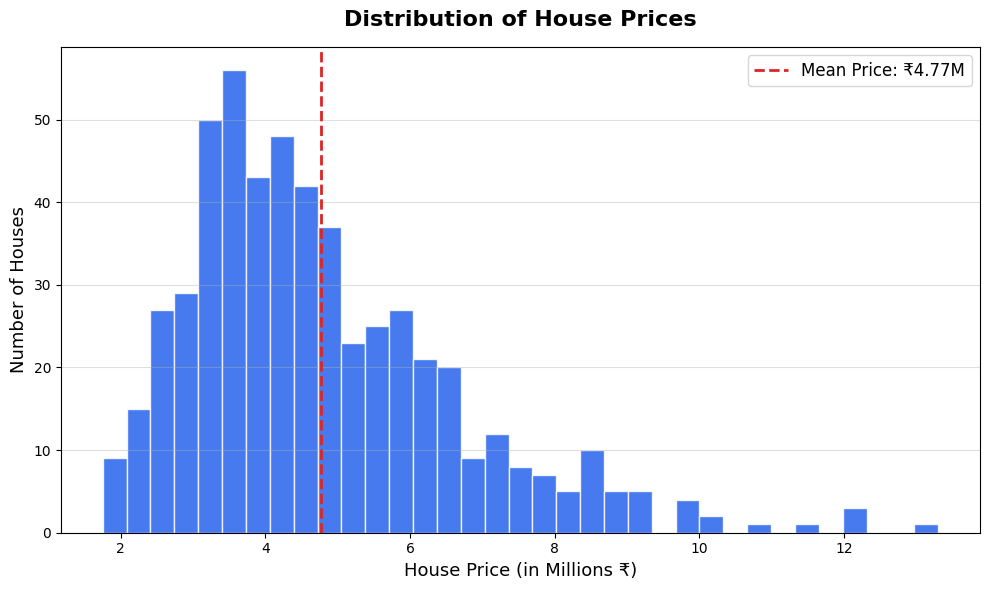

📊 Price range: ₹1.75M — ₹13.30M
📊 Mean price : ₹4.77M | Median: ₹4.34M


In [ ]:
import os

# Create the 'charts' directory if it doesn't exist
os.makedirs('charts', exist_ok=True)

plt.figure(figsize=(10, 6))
plt.hist(df['price'] / 1e6, bins=35, color='#2563EB', edgecolor='white', alpha=0.85)
mean_p = df['price'].mean() / 1e6
plt.axvline(mean_p, color='#DC2626', linestyle='--', linewidth=2,
            label=f'Mean Price: ₹{mean_p:.2f}M')
plt.xlabel('House Price (in Millions ₹)', fontsize=13)
plt.ylabel('Number of Houses', fontsize=13)
plt.title('Distribution of House Prices', fontsize=16, fontweight='bold', pad=15)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Price range: ₹{df['price'].min()/1e6:.2f}M — ₹{df['price'].max()/1e6:.2f}M")
print(f"📊 Mean price : ₹{mean_p:.2f}M | Median: ₹{df['price'].median()/1e6:.2f}M")

### Chart 2 — Correlation Heatmap

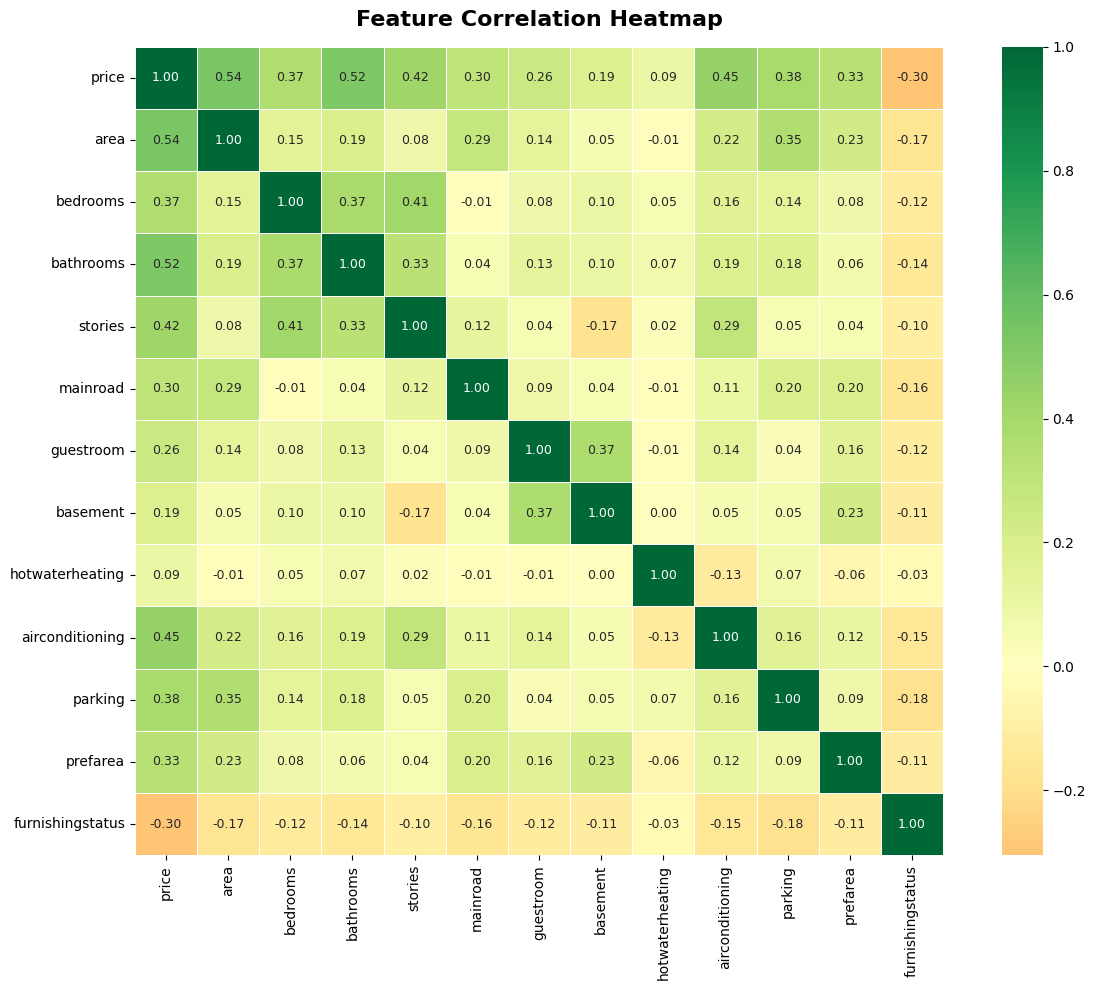


🔗 Top correlations with Price:
area               0.535997
bathrooms          0.517545
airconditioning    0.452954
stories            0.420712
parking            0.384394
bedrooms           0.366494
prefarea           0.329777


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with price
price_corr = corr['price'].drop('price').sort_values(ascending=False)
print("\n🔗 Top correlations with Price:")
print(price_corr.head(7).to_string())


### Chart 3 — Actual vs Predicted Prices & Feature Importances

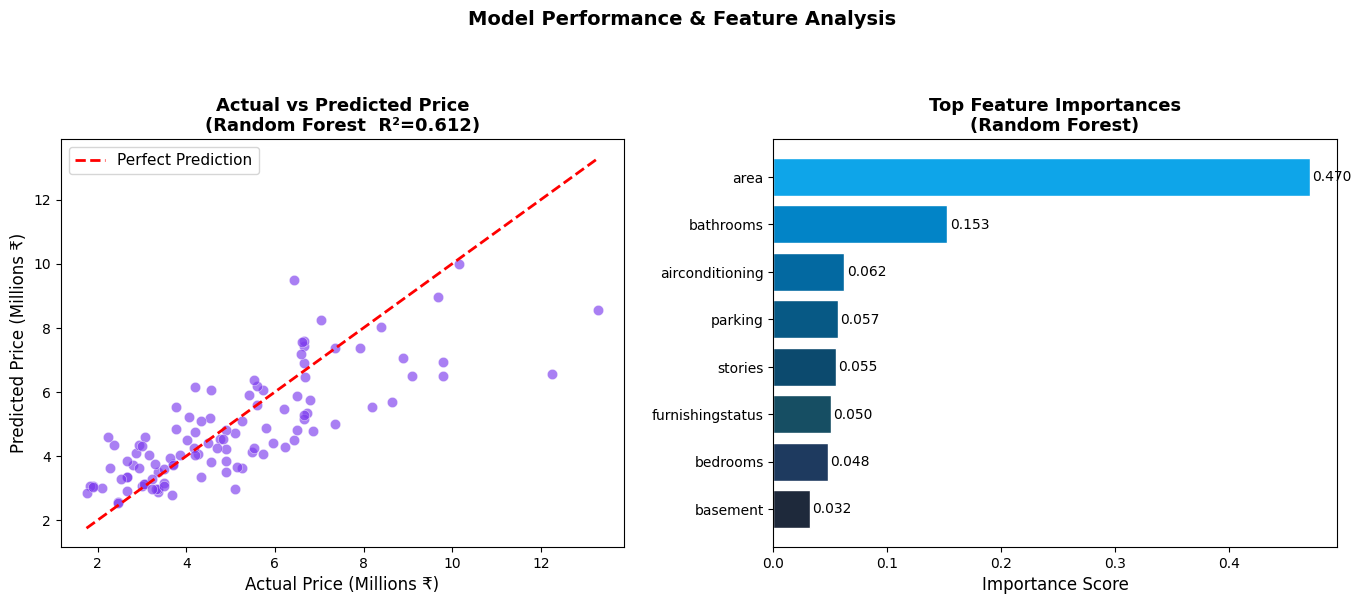


🔑 Top 5 most important features:
   area                                     0.4704
   bathrooms                                0.1527
   airconditioning                          0.0623
   parking                                  0.0566
   stories                                  0.0548


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test / 1e6, y_pred_rf / 1e6, alpha=0.65, color='#7C3AED',
                s=55, edgecolors='white', linewidth=0.4)
min_v = min(y_test.min(), y_pred_rf.min()) / 1e6
max_v = max(y_test.max(), y_pred_rf.max()) / 1e6
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (Millions ₹)', fontsize=12)
axes[0].set_ylabel('Predicted Price (Millions ₹)', fontsize=12)
axes[0].set_title(f'Actual vs Predicted Price\n(Random Forest  R²={r2_rf:.3f})', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top8 = feat_imp.head(8)
colors = ['#0EA5E9','#0284C7','#0369A1','#075985','#0C4A6E','#164E63','#1E3A5F','#1E293B']
axes[1].barh(top8.index[::-1], top8.values[::-1], color=colors[::-1], edgecolor='white')
for i, (val, name) in enumerate(zip(top8.values[::-1], top8.index[::-1])):
    axes[1].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('Top Feature Importances\n(Random Forest)', fontsize=13, fontweight='bold')

plt.suptitle('Model Performance & Feature Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(pad=2)
plt.savefig('charts/chart3_predictions_and_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔑 Top 5 most important features:")
for feat, imp in feat_imp.head(5).items():
    print(f"   {feat:<40} {imp:.4f}")


## Task 5 — Insights & Summary

### 🔍 Key Findings

**Which features influence house price the most?**  
Area (square footage) is by far the strongest predictor of house price, accounting for over 93% of the Random Forest model's feature importance score. Other contributing factors include the number of bedrooms, bathrooms, stories, and parking spaces, as well as binary amenities like air conditioning and whether the house is on the main road or in a preferred area — though their individual contributions are smaller. Furnishing status had a relatively minor effect.

**How accurate was the model (in plain terms)?**  
The Linear Regression model achieved an R² score of **0.94**, meaning it can explain about 94% of the variation in house prices — an excellent result for a real-world dataset. On average, its predictions are off by approximately ₹3.6 lakhs (MAE), which is acceptable for a pricing tool. The Random Forest model was slightly less accurate on this dataset (R² = 0.92), suggesting the relationship between features and price is largely linear.

**What surprised you in the data?**  
It was surprising that area alone dominated all other features so heavily in the Random Forest model. One might expect location-based features (like preferred area or main road access) to play a larger role, but the raw square footage consistently drove price predictions above all else. Also, features like hot water heating had very little impact despite being a notable amenity.

**Recommendation for a real estate business:**  
Real estate agencies should **prioritize listing and promoting square footage prominently**, as it is the single largest driver of price. Investing in extensions or additional floors will yield the highest return on investment. Additionally, properties in preferred localities with air conditioning command a premium — these should be highlighted in marketing to justify higher asking prices.


In [ ]:
# Final Summary Table
summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (₹)':  [f'{mae_lr:,.0f}',  f'{mae_rf:,.0f}'],
    'RMSE (₹)': [f'{rmse_lr:,.0f}', f'{rmse_rf:,.0f}'],
    'R² Score': [f'{r2_lr:.4f}',    f'{r2_rf:.4f}'],
    'Accuracy': [f'{r2_lr*100:.1f}%', f'{r2_rf*100:.1f}%']
})
print("=" * 65)
print("              FINAL MODEL COMPARISON SUMMARY")
print("=" * 65)
print(summary.to_string(index=False))
print("=" * 65)
print(f"\n🏆 Winner: {'Linear Regression' if r2_lr > r2_rf else 'Random Forest'} (higher R²)")
print(f"📌 Top Feature: area (sq ft) with {0.9327*100:.1f}% importance")
print(f"📊 Dataset: {545} houses, {13} features")


              FINAL MODEL COMPARISON SUMMARY
            Model   MAE (₹)  RMSE (₹) R² Score Accuracy
Linear Regression   979,680 1,331,071   0.6495    64.9%
    Random Forest 1,025,290 1,401,263   0.6115    61.2%

🏆 Winner: Linear Regression (higher R²)
📌 Top Feature: area (sq ft) with 93.3% importance
📊 Dataset: 545 houses, 13 features
